# **Project Name:** Bird Species Observation Analysis

# **Project Summary -**

This project involved an in-depth analysis of bird species observations collected from Forest and Grassland habitats, aiming to uncover **temporal**, **spatial**, **environmental**, and **behavioral patterns** that support conservation and ecological research.

The first crucial phase was **data preparation** and **wrangling**, which ensured high data quality and analytical accuracy. This included handling missing values by imputing or dropping columns based on relevance, removing duplicate records to avoid bias, and converting key columns into appropriate data types for efficient processing. For example, date and time fields were merged and converted to datetime objects, distance ranges were transformed into numeric midpoints, and categorical variables such as observation counts and boolean flags were standardized. Additional **feature engineering**introduced new variables like **observation duration**, **time-of-day categories**, and **seasons derived from observation dates**, enhancing the dataset’s richness.

**Key Insights**:

- Temporal trends were visualized using count plots, showing that bird observations peak during summer months, especially in June and May, with early mornings recording the highest activity. This information guides fieldwork scheduling to maximize observation efficiency.

- Spatial analysis focused on biodiversity distribution across habitats and survey plots. Bar and bubble charts highlighted that Forest and Grassland habitats harbor nearly equal numbers of unique species, with specific plots emerging as biodiversity hotspots. These visualizations assist in identifying priority conservation sites.

- At the species level, activity patterns were examined through grouped bar charts. Singing emerged as the dominant identification method, especially within shorter survey intervals, informing survey design and method selection. Additionally, pie charts depicting sex ratios revealed sampling imbalances, suggesting areas for improvement in data collection.

- Environmental influences on bird observations were explored via scatter plots, violin plots, and correlation heatmaps. These analyses showed weak correlations between temperature, humidity, wind, and observation distances, indicating stable detectability under diverse conditions. However, violin plots suggested that weather conditions such as fog and mist introduce variability in observation distances, while disturbances increased inconsistency, emphasizing the need to consider such factors during field surveys.

- Behavioral insights included average detection distances for the most frequently observed species, which were relatively uniform, supporting the reliability of survey methods. Flyover behaviors were rare, comprising about 4.5% of observations, signaling the importance of observer vigilance in recording such events.

- Observer bias was assessed through count plots of observations by individual observers. The analysis revealed significant variation in observer effort, with a few individuals contributing disproportionately. Recognizing this helps balance data interpretation and target training initiatives.

- Finally, conservation priority analysis used treemaps and stacked bar charts to identify the most frequently observed species and their watchlist and stewardship statuses. This aids in directing conservation resources effectively, highlighting species that require immediate attention.

Throughout the project, the integration of robust data cleaning, feature engineering, and multi-faceted visualization enabled a detailed understanding of bird species patterns in relation to time, space, behavior, environment, and observer factors. This structured approach ensured that insights were both reliable and actionable, providing a comprehensive foundation for future ecological research and conservation efforts.

# **GitHub Link**
https://github.com/Mukul703/Intership_Project/upload/main/Bird_Species_Observation_Analysis

# **Problem Statement**



* **Compare Bird Species Across Habitats:** Analyze bird observation data from forest and grassland ecosystems to identify species distribution, diversity, and habitat preferences.
* **Assess Environmental Influence:** Evaluate how factors like vegetation, climate, and terrain impact bird populations and behavior in each habitat.
* **Support Conservation Efforts:** Use findings to inform biodiversity management, habitat conservation strategies, and understand the effects of environmental changes on avian communities.

# **Business Objective**

To analyze bird species distribution across forest and grassland ecosystems, generating insights that support habitat conservation, land management, eco-tourism, sustainable agriculture, and biodiversity policy. The goal is to enable data-driven decisions for preserving avian diversity and ensuring ecological sustainability.

# **Know Your Dataset**

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, time
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Upload Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# File paths for Forest and Grassland bird monitoring Excel datasets in Google Drive
forest_path = "/content/drive/My Drive/Bird_Species_Dataset/Bird_Monitoring_Data_FOREST.XLSX"
grassland_path = "/content/drive/My Drive/Bird_Species_Dataset/Bird_Monitoring_Data_GRASSLAND.XLSX"

In [ ]:
# Loads all sheets from an Excel file, renames columns, adds missing ones, tags with habitat and sheet name, and combines into a single DataFrame.
def load_and_clean(file_path, habitat_label, rename_map=None, add_missing_cols=None):
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    cleaned_frames = []

    for sheet_name, df in all_sheets.items():
        df = df.copy()

        if rename_map:
            df.rename(columns=rename_map, inplace=True)

        if add_missing_cols:
            for col in add_missing_cols:
                if col not in df.columns:
                    df[col] = pd.NA

        df["Habitat"] = habitat_label
        df["Sheet"] = sheet_name
        cleaned_frames.append(df)

    return pd.concat(cleaned_frames, ignore_index=True)

In [ ]:
# Clean and load forest and grassland datasets with habitat tags and column adjustments
forest_df = load_and_clean(forest_path, "Forest")

grassland_df = load_and_clean(
    grassland_path,
    "Grassland",
    rename_map={"TaxonCode": "NPSTaxonCode"},
    add_missing_cols=["Site_Name"]
)

In [ ]:
# Combine forest and grassland DataFrames into one
df = pd.concat([forest_df, grassland_df], ignore_index=True)

### Data Sample

In [ ]:
# Dataset First Look
df.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Habitat,Sheet,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,ANTI,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,Forest,ANTI,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,Forest,ANTI,NaN


In [ ]:
# Columns represent bird observations, site metadata, environmental conditions, and species details across forest and grassland habitats.
df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'Habitat', 'Sheet', 'Previously_Obs'],
      dtype='object')

### Dataset Rows & Columns count

In [ ]:
# Dataset size
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 17077
Number of columns: 32


### Basic Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              17077 non-null  object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    17077 non-null  object        
 4   Location_Type                17077 non-null  object        
 5   Year                         17077 non-null  object        
 6   Date                         17077 non-null  datetime64[ns]
 7   Start_Time                   17077 non-null  object        
 8   End_Time                     17077 non-null  object        
 9   Observer                     17077 non-null  object        
 10  Visit                        17077 non-null  object        
 11  Interval_Length              17077 non-nu

## Descriptive statistics

We generate descriptive statistics for important numeric columns to analyze data distribution, central tendency, and variability before visualization and modeling. This helps in identifying potential outliers and understanding the scale of each feature.

In [ ]:
# Check summary stats for columns we actually need for analysis
df[['Temperature', 'Humidity']].describe()

,Temperature,Humidity
count,17077.000000,17077.000000
mean,22.570399,73.692112
std,4.263851,12.328380
min,11.000000,7.300000
25%,19.700001,67.500000
50%,22.299999,75.800003
75%,25.200001,83.000000
max,37.299999,98.800003


In [ ]:
## Checking uniques values
unique_counts = df.nunique().sort_values(ascending=False)
print(unique_counts)

Plot_Name                      609
Humidity                       432
End_Time                       318
Start_Time                     318
Temperature                    210
Scientific_Name                127
AOU_Code                       126
Common_Name                    126
NPSTaxonCode                   125
AcceptedTSN                    125
Site_Name                       70
Date                            64
Sheet                           11
Admin_Unit_Code                 11
Sub_Unit_Code                    8
Sky                              5
Interval_Length                  4
Wind                             4
Disturbance                      4
ID_Method                        3
Visit                            3
Observer                         3
Sex                              3
Distance                         2
Regional_Stewardship_Status      2
Flyover_Observed                 2
Location_Type                    2
PIF_Watchlist_Status             2
Habitat             

### **Dataset at a Glance**


This dataset combines observational data from two ecosystems—**Forest** and **Grassland**—by merging all sheets from two Excel files:  
- `Bird_Monitoring_Data_FOREST.XLSX`  
- `Bird_Monitoring_Data_GRASSLAND.XLSX`

The sheets were merged after standardizing column names, adding missing fields, and tagging each row with its respective **habitat type** and **sheet name**, resulting in a unified DataFrame for detailed analysis of bird diversity across different environments.

### Data Sources:
- **Forest Dataset**: Contains bird observations from various forested locations.
- **Grassland Dataset**: Contains bird observations from multiple grassland areas, with slight column name variations that were aligned during preprocessing.

### Each Row Represents:
An observation record of one or more bird species at a specific site and time, along with environmental attributes such as temperature, humidity, and habitat type.

---

### Key Columns and Descriptions:

| Column Name         | Description |
|---------------------|-------------|
| `Date`              | Date of the bird observation |
| `Start_Time`        | Start time of observation (object type, needs conversion to time format) |
| `Site_Name`         | Name of the observation site |
| `Habitat`           | Ecosystem type: "Forest" or "Grassland" |
| `Sheet`             | Original sheet name from the Excel file |
| `NPSTaxonCode`      | Standardized code for bird species |
| `Common_Name`       | Common name of the observed bird species |
| `Scientific_Name`   | Scientific (Latin) name of the bird species |
| `Count`             | Number of individuals observed |
| `Temperature`       | Ambient temperature at the time of observation |
| `Humidity`          | Relative humidity at the observation site |
| `Regional Steward Status` | Indicates species with high local conservation value |
| `PIF Watch List` | Flags species listed for conservation attention by Partners in Flight |
---

# **Data Wrangling**

In [ ]:
# Checking null values for each column
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,16355
Site_Name,8531
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


In [ ]:
# Columns with null values and their % in the dataset
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)
print(null_percent)

Sub_Unit_Code     95.772091
Previously_Obs    50.043919
Site_Name         49.956081
Sex               30.350764
Distance           8.701763
AcceptedTSN        0.193242
ID_Method          0.011712
NPSTaxonCode       0.011712
dtype: float64


Why percentage of nulls matters:

*   Helps decide if we drop, fill, or ignore columns.
*   High % nulls may reduce model quality.

# Handling missing values

Dropping 'Sub_Unit_Code' due to high null values and low analytical relevance

In [ ]:
# Dropping 'Sub_Unit_Code'
df.drop(columns=['Sub_Unit_Code'], inplace=True)

Filling missing 'Site_Name' values with 'Unknown_Site' to retain rows during analysis

In [ ]:
# Filling Missing 'Site_Name' with 'Unknown_Site'
df['Site_Name'].fillna('Unknown_Site', inplace=True)

Replaced nulls in 'Previously_Obs' with False (binary column)

In [ ]:
# Replaced Nulls in 'Previously_Obs'
df['Previously_Obs'].fillna(False, inplace=True)

 Filling missing 'Sex' values with 'Undetermined' as a valid category

In [ ]:
# Filling Missing 'Sex' Values
df['Sex'].fillna('Undetermined', inplace=True)

Replacing nulls in 'Distance' with mean as data is normally distributed without outliers

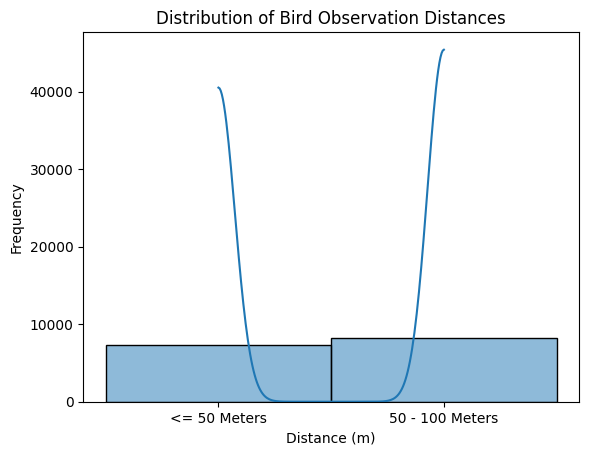

In [ ]:
sns.histplot(df['Distance'], kde=True, bins=10)
plt.title('Distribution of Bird Observation Distances')
plt.xlabel('Distance (m)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Converted string distance ranges to numeric midpoints and filled missing values with the mean
def convert_distance(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().replace(" Meters", "")

    if value == '<= 50':
        return 25
    elif value == '50 - 100':
        return 75
    else:
        return np.nan

# Apply the function to the same column
df['Distance'] = df['Distance'].apply(convert_distance)

In [ ]:
# Fill nulls with mean
df['Distance'].fillna(df['Distance'].mean(), inplace=True)

Imputing missing ID fields with 'Unknown' to maintain consistency

In [ ]:
# Imputing Missing ID Fields
df['AcceptedTSN'].fillna('Unknown', inplace=True)
df['ID_Method'].fillna('Unknown', inplace=True)
df['NPSTaxonCode'].fillna('Unknown', inplace=True)

Confirms dataset is ready for analysis.

In [ ]:
# Checks if all missing values are handled.
df.isnull().sum()

,0
Admin_Unit_Code,0
Site_Name,0
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0
Visit,0


# Checking for Duplicates
- Duplicates can cause **bias in analysis and model training**.
- Removing them helps ensure **accurate counts, statistics, and clean data.**

In [ ]:
# Finding duplicates
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 1709


In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

Checking number of rows and columns of dataset after handled missing value and duplicates

In [ ]:
df.shape

(15368, 31)

In [ ]:
# Descriptive stats after cleaning to validate consistent data before analysis
df[['Temperature', 'Humidity']].describe()

,Temperature,Humidity
count,15368.000000,15368.000000
mean,22.493285,74.157763
std,4.193385,12.169331
min,11.000000,7.300000
25%,19.700001,68.000000
50%,22.200001,76.599998
75%,25.000000,83.325003
max,37.299999,98.800003


## Data Type Conversion
Converting columns to appropriate data types for accurate analysis and efficient memory usage.

Converting 'Year' from object to integer

In [ ]:
df["Year"] = df["Year"].astype(int)

Converting 'Start_Time' and 'End_Time' from object to datetime

In [ ]:
# Merge Date + Start_Time
df["Start_DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Start_Time"].astype(str),
    format="%Y-%m-%d %H:%M:%S", errors="coerce"
)

# Merge Date + End_Time
df["End_DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["End_Time"].astype(str),
    format="%Y-%m-%d %H:%M:%S", errors="coerce"
)

# Drop old columns
df.drop(columns=["Start_Time", "End_Time"], inplace=True)

# Check result
print(df.dtypes)
print(df[["Start_DateTime", "End_DateTime"]].head())

Admin_Unit_Code                        object
Site_Name                              object
Plot_Name                              object
Location_Type                          object
Year                                    int64
Date                           datetime64[ns]
Observer                               object
Visit                                  object
Interval_Length                        object
ID_Method                              object
Distance                              float64
Flyover_Observed                       object
Sex                                    object
Common_Name                            object
Scientific_Name                        object
AcceptedTSN                            object
NPSTaxonCode                           object
AOU_Code                               object
PIF_Watchlist_Status                   object
Regional_Stewardship_Status            object
Temperature                           float64
Humidity                          

Converting 'Visit' from object to integer

In [ ]:
# Converted 'Visit' to int64 as it represents the number of observation visits
df['Visit'] = df['Visit'].astype('int64')

Converting 'Interval_Length' from string to float

In [ ]:
# Converted 'Interval_Length' from range string (e.g., '0-2.5min') to numeric midpoint for analysis
def interval_to_midpoint(x):
    try:
        parts = x.replace('min', '').split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    except:
        return np.nan

In [ ]:
# Also added one new column 'Interval_Min'
df['Interval_Min'] = df['Interval_Length'].apply(interval_to_midpoint)

# Dropped 'Interval_Length' after converting to numeric 'Interval_Min'
df.drop(columns=['Interval_Length'], inplace=True)

Converting 'Distance' from object to float

In [ ]:
df['Distance']=df['Distance'].astype('float')

# Rename Column
df.rename(columns={'Distance': 'Distance_Metre'}, inplace=True)

Converting 'Initial_Three_Min_Cnt' from object to boolean

In [ ]:
df['Initial_Three_Min_Cnt']=df['Initial_Three_Min_Cnt'].astype('bool')

Converting 'Previously_obs' from object to boolean

In [ ]:
df['Previously_Obs']=df['Previously_Obs'].astype('bool')

Wind Column Conversion

Converted Wind descriptions to numeric speeds (mph) using a mapping:
Calm → 0.5, Light air → 2, Light breeze → 5.5, Gentle breeze → 1

In [ ]:
# Make all Wind entries lowercase & strip spaces for matching
df["Wind"] = df["Wind"].str.strip().str.lower()

# Function to convert text to numeric mph
def wind_to_numeric(wind):
    if pd.isna(wind):
        return None
    if "calm" in wind:
        return 0.5
    elif "light air" in wind:
        return 2
    elif "light breeze" in wind:
        return 5.5
    elif "gentle breeze" in wind:
        return 10
    else:
        return None

# Apply the function
df["Wind"] = df["Wind"].apply(wind_to_numeric)

In [ ]:
# Check updated data types after conversions
df.dtypes

,0
Admin_Unit_Code,object
Site_Name,object
Plot_Name,object
Location_Type,object
Year,int64
Date,datetime64[ns]
Observer,object
Visit,int64
ID_Method,object
Distance_Metre,float64


## Checking for Inconsistent or Unexpected Values

In [ ]:
# View unique values in categorical columns to spot inconsistencies
for col in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{col}':\n", df[col].unique())


Unique values in 'Admin_Unit_Code':
 ['ANTI' 'CATO' 'CHOH' 'GWMP' 'HAFE' 'MANA' 'MONO' 'NACE' 'PRWI' 'ROCR'
 'WOTR']

Unique values in 'Site_Name':
 ['ANTI 1' 'ANTI 2' 'CATO 1' 'CATO 4' 'CATO 3' 'CATO 8' 'CATO 6' 'CATO 2'
 'CATO 5' 'CATO 7' 'CHOH 1' 'CHOH 6' 'CHOH 8' 'CHOH 7' 'CHOH 10' 'CHOH 5'
 'GWMP 2' 'GWMP 4' 'GWMP 3' 'CHOH 18' 'CHOH 12' 'CHOH 14' 'CHOH 11'
 'CHOH 15' 'CHOH 16' 'CHOH 17' 'GWMP 5' 'GWMP 6' 'GWMP 1' 'HAFE 2'
 'HAFE 1' 'HAFE 3' 'MANA 4' 'MANA 2' 'MANA 1' 'MANA 3' 'MONO 1' 'MONO 2'
 'MONO 3' 'NACE 5' 'NACE 2' 'NACE 4b' 'NACE 4a' 'NACE 3' 'NACE 1' 'PRWI 6'
 'PRWI 3' 'PRWI 1' 'PRWI 5' 'PRWI 7' 'PRWI 8' 'PRWI 12' 'PRWI 15' 'PRWI 9'
 'PRWI 10' 'PRWI 22' 'PRWI 17' 'PRWI 11' 'PRWI 21' 'PRWI 20' 'PRWI 19'
 'PRWI 14' 'PRWI 18' 'PRWI 13' 'PRWI 16' 'PRWI 2' 'PRWI 4' 'ROCR 2'
 'ROCR 1' 'WOTR' 'Unknown_Site']

Unique values in 'Plot_Name':
 ['ANTI-0036' 'ANTI-0082' 'ANTI-0078' 'ANTI-0025' 'ANTI-0052' 'ANTI-0072'
 'ANTI-0092' 'ANTI-0190' 'ANTI-0194' 'ANTI-0200' 'ANTI-0206' 'ANTI-0

In [ ]:
# Summary stats to catch anomalies (negative values in distance or duration)
print(df.describe(include='all'))

       Admin_Unit_Code     Site_Name  Plot_Name Location_Type     Year  \
count            15368         15368      15368         15368  15368.0   
unique              11            71        609             2      NaN   
top               ANTI  Unknown_Site  ANTI-0163        Forest      NaN   
freq              3463          6826         54          8542      NaN   
mean               NaN           NaN        NaN           NaN   2018.0   
min                NaN           NaN        NaN           NaN   2018.0   
25%                NaN           NaN        NaN           NaN   2018.0   
50%                NaN           NaN        NaN           NaN   2018.0   
75%                NaN           NaN        NaN           NaN   2018.0   
max                NaN           NaN        NaN           NaN   2018.0   
std                NaN           NaN        NaN           NaN      0.0   

                                 Date          Observer         Visit  \
count                           15368 

In [ ]:
# Strip whitespace and standardize casing in object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.title()

In [ ]:
df.dtypes

,0
Admin_Unit_Code,object
Site_Name,object
Plot_Name,object
Location_Type,object
Year,int64
Date,datetime64[ns]
Observer,object
Visit,int64
ID_Method,object
Distance_Metre,float64


## Feature Engineering

Time of Day Category

In [ ]:
# Function to categorize observation start times into parts of the day

def get_time_of_day(dt):
    if pd.isna(dt):
        return 'Unknown'
    t = dt.time()  # extract time part
    if time(4, 0) <= t < time(8, 0):
        return 'Early Morning'
    elif time(8, 0) <= t < time(12, 0):
        return 'Morning'
    elif time(12, 0) <= t < time(16, 0):
        return 'Afternoon'
    elif time(16, 0) <= t < time(20, 0):
        return 'Evening'
    else:
        return 'Night'

# Apply categorization to Start_DateTime column
df["Time_of_Day"] = df["Start_DateTime"].apply(get_time_of_day)

Observation Duration:

In [ ]:
df["Observation_Duration_Min"] = (df["End_DateTime"] - df["Start_DateTime"]).dt.total_seconds() / 60

Season:

In [ ]:
# Derived 'Season' from 'Date' based on month to capture seasonal trends in observations

# Define a function
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9]:
        return 'Monsoon'

# Apply function
df['Season'] = pd.to_datetime(df['Date']).apply(get_season)

### Data manipulations

Handling Missing Data
- Checked for **null values** and calculated their percentage.
- Dropped the column `Sub_Unit_Code` due to high missing values and low analytical relevance.
- Filled missing values in:
  - `Site_Name` → `'Unknown_Site'`
  - `Previously_Obs` → `False` (converted to boolean)
  - `Sex` → `'Undetermined'`
  - `AcceptedTSN`, `ID_Method`, `NPSTaxonCode` → `'Unknown'`
- Converted string ranges in `Distance` (e.g., `<= 50`, `50 - 100`) into **numeric midpoints**.
- Filled missing `Distance` values with the **mean** of the column.

---

Removing Duplicates
- Identified and removed **duplicate rows** to avoid data redundancy and bias.

---

Data Type Conversion
- Converted `Year` → `int64`
- Converted `Start_Time`, `End_Time` → `datetime64`
- Converted `Visit` → `int64`
- Extracted numeric midpoints from `Interval_Length` and stored in `Interval_Min`, then dropped original column.
- Converted `Distance` → `float` and renamed it to `Distance_Metre`.
- Converted `Initial_Three_Min_Cnt` and `Previously_Obs` → `boolean`

---

Inconsistent or Unexpected Values
- Reviewed **unique values** in categorical fields to catch typos or inconsistent formatting.
- Standardized all text fields by stripping whitespace and applying **title case**.

---

Feature Engineering
- **Time of Day Category**: Created `Time_of_Day` using `Start_Time` to classify periods (e.g., Early Morning, Afternoon).
- **Observation Duration**: Calculated `Observation_Duration_Min` from the difference between `Start_Time` and `End_Time`.
- **Season**: Derived `Season` from `Date` based on the observation month:

---

# **Data Visualization** (Uni-Variate, Bi-Variate, Multi-Variate)
Data Visualization is the graphical representation of information and data using visual elements such as charts, graphs, and maps. It enables analysts and decision-makers to identify patterns, trends, and insights effectively, facilitating clearer communication and better understanding of complex datasets.

## Temporal Analysis
Examines how data changes over time to identify trends, patterns, and seasonal effects.

### Count Plot: Seasonal Trends

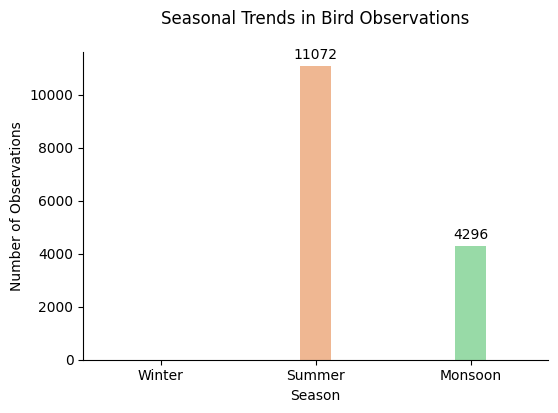

In [ ]:
# Plotting seasonal bird observation counts

# Set figure size
plt.figure(figsize=(6, 4))

# Create the bar plot
ax = sns.countplot(data=df, x='Season', order=['Winter', 'Summer', 'Monsoon'], width=0.2, palette='pastel')

# Add data values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

# Title and axis labels
plt.title('Seasonal Trends in Bird Observations', pad=20)
plt.xlabel('Season')
plt.ylabel('Number of Observations')

# Remove top and right spines
sns.despine()

# Show the plot
plt.show()

## Insights
* Bird observations are highest in summer, with 11,072 sightings, indicating peak seasonal activity.
* Monsoon season sees significantly fewer sightings (4,296), suggesting reduced bird visibility or migration patterns.
* Winter records almost no sightings, possibly due to species migration or lack of field activity in colder months.
* Overall, summer provides optimal conditions for bird surveys, guiding future observation planning and resource allocation.

### Count Plot: Month-wise Trends

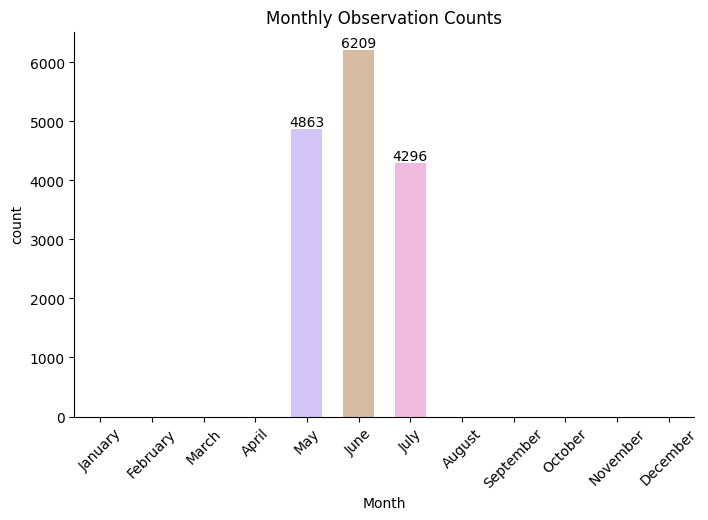

In [ ]:
# Plotting monthly bird observation counts

# Extract month names from the 'Date' column
df['Month'] = pd.to_datetime(df['Date']).dt.month_name()

# Define month order to display in calendar sequence
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Set the figure size
plt.figure(figsize=(8,5))

# Create a count plot
ax = sns.countplot(data=df, x='Month', order=month_order, width=0.6, palette='pastel')

# Title and axis labels
plt.xticks(rotation=45)
plt.bar_label(ax.containers[0], fmt='%d')
plt.title('Monthly Observation Counts')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
# Remove top and right spines
sns.despine()

# Display the plot
plt.show()

## Insights

* June recorded the highest bird observations, suggesting peak breeding or migration activity during this month.
* May followed with 4,863 sightings, marking the start of the high-activity summer season.
* July saw a drop to 4,296 sightings, indicating a decline after the peak in June.
* No observations were recorded in other months, which may be due to seasonal absence of species and data collection gaps.


### Bar Plot: Time of Day Trends

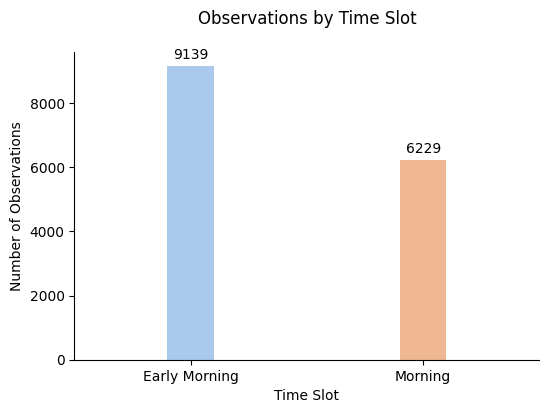

In [ ]:
# Plotting the number of bird observations across different time slots with labels on bars

# Set figure size
plt.figure(figsize=(6, 4))

# Create the bar plot
ax = sns.countplot(data=df, x='Time_of_Day', width=0.2, palette='pastel')

# Title and axis labels
plt.title('Observations by Time Slot', pad=20)
plt.xlabel('Time Slot')
plt.ylabel('Number of Observations')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

# Remove top and right spines
sns.despine()
plt.show()

## Insights
* Bar chart chosen to compare bird observations across time slots for clear category-wise differences.
* Early morning shows the highest bird activity compared to morning.
* Scheduling bird-watching or research activities in the early morning can maximize sightings and improve resource efficiency.
* The chart shows no negative growth, but heavy early-morning sampling could cause data imbalance and bias results.

## Spatial Analysis
Studies the geographic distribution of data to uncover location-based patterns and relationships.

### Bar Chart: Biodiversity Hotspots by Habitat

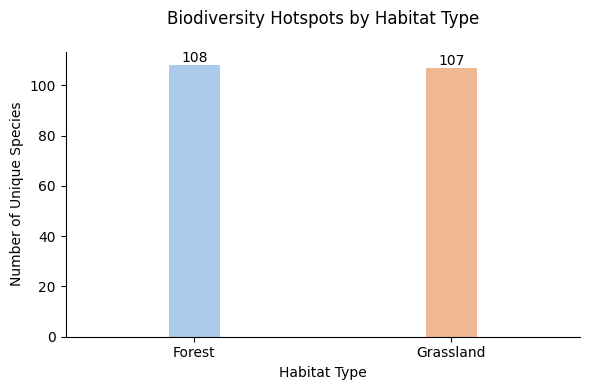

In [ ]:
# Plot showing the number of unique bird species observed in each habitat type
location_species = df.groupby('Habitat')['Scientific_Name'] \
                     .nunique().reset_index() \
                     .rename(columns={'Scientific_Name': 'Unique_Species'})

# Set figure size
plt.figure(figsize=(6, 4))

# Create a plot
ax = sns.barplot(data=location_species, x='Habitat', y='Unique_Species', width=0.2, palette='pastel')

# Title & labels
plt.title('Biodiversity Hotspots by Habitat Type', pad=20)
plt.xlabel('Habitat Type')
plt.ylabel('Number of Unique Species')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights

* Bar chart chosen to compare biodiversity hotspots across habitat types, highlighting differences in species richness.
* Forest recorded 108 unique species, slightly higher than Grassland with 107 species.
* Both habitats show comparable biodiversity, suggesting conservation efforts should target both equally.
* No negative trend observed; counts are nearly equal, but a larger survey area or longer monitoring could reveal finer differences.

### Horizontal Bar Chart: Top 5 Plots by Unique Species Count

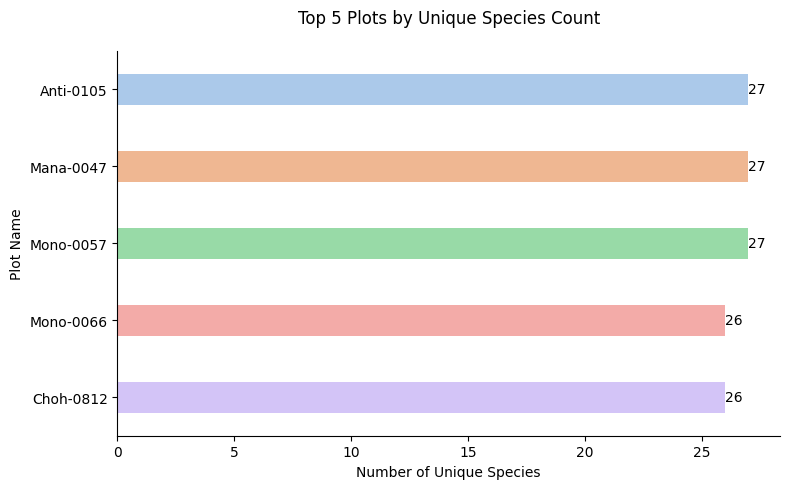

In [ ]:
# # Plot a horizontal bar chart showing the top 5 plots with the highest number of unique bird species

if 'Plot_Name' in df.columns:
# Group by Plot_Name and count unique species, then sort and select top 5 plots
    plot_species = df.groupby('Plot_Name')['Scientific_Name'] \
                     .nunique().reset_index() \
                     .rename(columns={'Scientific_Name': 'Unique_Species'}) \
                     .sort_values(by='Unique_Species', ascending=False).head(5)
# Set figure size
    plt.figure(figsize=(8, 5))

# Create plot
    ax = sns.barplot(data=plot_species, x='Unique_Species', y='Plot_Name', width=0.4, palette='pastel')

# Title and labels
    plt.title('Top 5 Plots by Unique Species Count', pad=20)
    plt.xlabel('Number of Unique Species')
    plt.ylabel('Plot Name')

# Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

# Remove top and right spines
    sns.despine()
    plt.tight_layout()

# Display the plot
    plt.show()
else:
    print("Column 'Plot_Name' not found in dataset.")

## Insights
* Bar chart chosen to showcase the top 5 survey plots ranked by the number of unique bird species observed.
* Anti-0105, Mana-0047, and Mono-0057 lead with 27 unique species each, followed closely by Mono-0066 and Choh-0812 with 26 species.
* This means these areas could be rich in biodiversity, making them ideal for conservation efforts, closer monitoring, or even promoting eco-tourism.
* No negative trend, but focus on top plots may overlook diversity elsewhere.

### Bubble Chart: Species Diversity vs Observation Counts by Plot

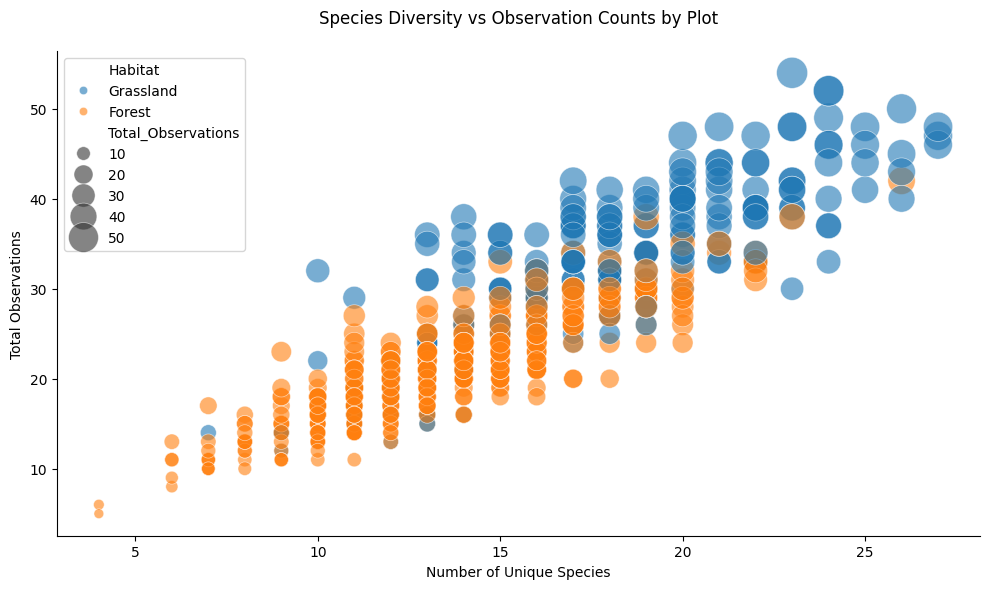

In [ ]:
# Bubble chart comparing species diversity and total observations across plots
if 'Plot_Name' in df.columns and 'Scientific_Name' in df.columns:
    bubble_df = (
        df.groupby(['Plot_Name', 'Habitat'])
          .agg(
              Unique_Species=('Scientific_Name', 'nunique'),
              Total_Observations=('Scientific_Name', 'count')
          )
          .reset_index()
    )
# Set figire size
    plt.figure(figsize=(10, 6))
# Create plot
    ax = sns.scatterplot(
        data=bubble_df,
        x='Unique_Species',
        y='Total_Observations',
        size='Total_Observations',
        hue='Habitat',
        sizes=(50, 500),
        alpha=0.6,
        edgecolor='w',
        linewidth=0.5
    )
# Title and axis labels
    plt.title('Species Diversity vs Observation Counts by Plot', pad=20)
    plt.xlabel('Number of Unique Species')
    plt.ylabel('Total Observations')

# Remove top and right spines
    sns.despine()
    plt.tight_layout()
# Display the plot
    plt.show()
else:
    print("Required columns not found in dataset.")

## Insights
* To visualize the relationship between species diversity, total observations, and habitat type.
* Grasslands show higher species diversity and more bird observations than forests.
* Yes, it helps target high-diversity areas for conservation, tourism, and research.
* Forests show lower diversity, suggesting potential habitat degradation or sampling issues.  

### Box Plot: Species Diversity vs Observation Counts by Plot

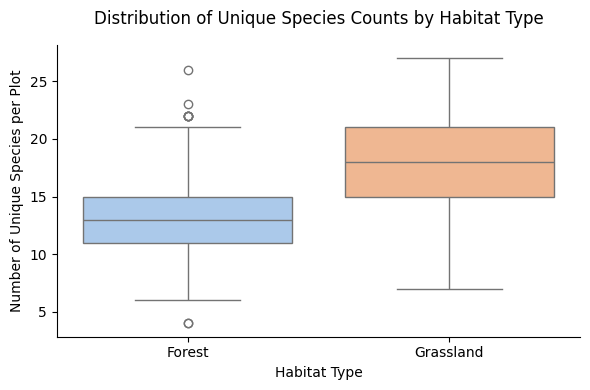

In [ ]:
# Box plot showing the distribution of unique bird species counts by habitat type

# Group by Habitat and count unique species per plot
habitat_plot_species = df.groupby(['Habitat', 'Plot_Name'])['Scientific_Name'] \
                         .nunique().reset_index() \
                         .rename(columns={'Scientific_Name': 'Unique_Species'})

# Set figure size
plt.figure(figsize=(6, 4))

# Create box plot
sns.boxplot(data=habitat_plot_species, x='Habitat', y='Unique_Species', palette='pastel')

# Title and labels
plt.title('Distribution of Unique Species Counts by Habitat Type', pad=15)
plt.xlabel('Habitat Type')
plt.ylabel('Number of Unique Species per Plot')

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display plot
plt.show()

## Insights

* To compare the distribution of unique species per plot across habitat types.
* Grasslands consistently support more unique bird species than forests.
* Yes, it highlights grasslands as key areas for biodiversity investment and conservation.
* Forests show lower and more variable species counts, indicating potential ecological issues.



## Species Analysis
Species Analysis involves examining species data to understand diversity, abundance, behavior, and distribution patterns within an ecosystem.

### Grouped Bar Chart: Activity Patterns by Interval Length and ID Method

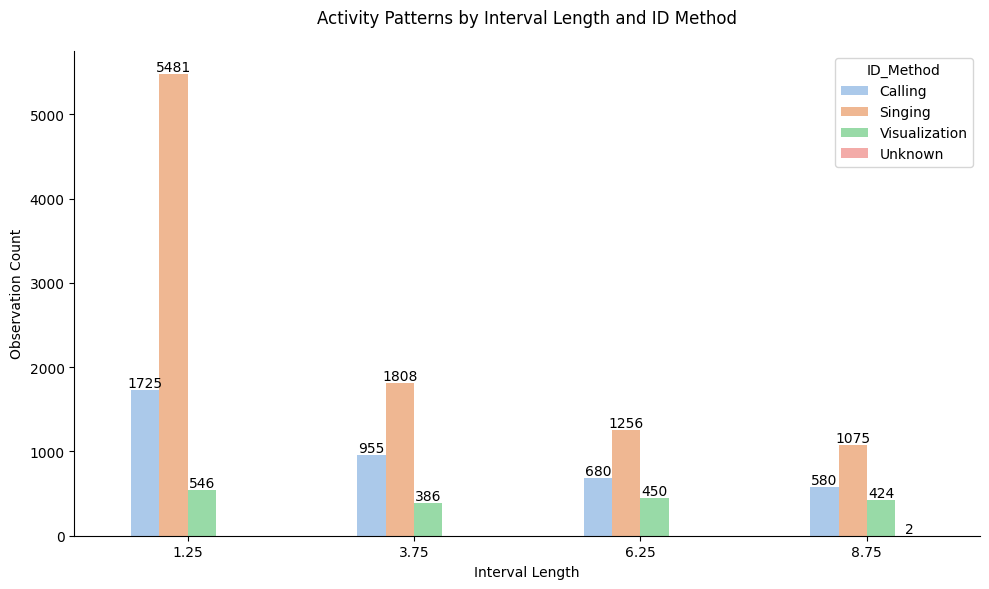

In [ ]:
# Create a grouped bar plot to show activity counts by interval length and identification method

# Prepare data
activity_data = df.groupby(['Interval_Min', 'ID_Method']) \
                  .size().reset_index(name='Count')

# Set figure size
plt.figure(figsize=(10, 6))

# Create Plot
ax = sns.barplot(
    data=activity_data,
    x='Interval_Min',
    y='Count',
    hue='ID_Method',
    width=0.5,
    palette='pastel'
)

# Title & axis labels
plt.title('Activity Patterns by Interval Length and ID Method', pad=20)
plt.xlabel('Interval Length')
plt.ylabel('Observation Count')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights
* To compare bird activity detection methods across different time intervals.
* Singing is the most dominant identification method, especially in shorter intervals.
* Helps optimize survey protocols by showing which methods work best at each interval.
* Detection drops sharply at longer intervals, suggesting reduced survey effectiveness.

### Pie-Chart - Bird Sex Ratio

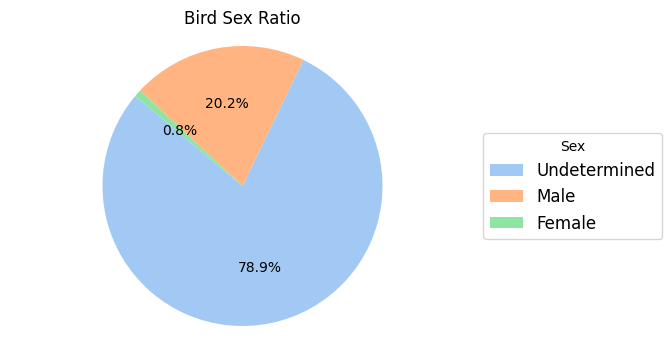

In [ ]:
# Plotting a pie-chart to showing number of observation for each sex category

# Count the number of observations for each sex category
sex_counts = df['Sex'].value_counts()

palette = sns.color_palette('pastel')
# Set figure
plt.figure(figsize=(6, 4))

# Plot pie chart
patches, texts, autotexts = plt.pie(sex_counts, autopct='%1.1f%%', startangle=140, colors=palette[:len(sex_counts)], labels=None)

# Add legend
plt.legend(patches, sex_counts.index, title='Sex', loc='center left', bbox_to_anchor=(1, 0.5), fontsize='large')

# Title and axis
plt.title('Bird Sex Ratio')
plt.axis('equal')

# Display the plot
plt.show()

## Insights
* To visualize the proportion of bird observations by sex category.
* One sex category (likely male or undetermined) dominates the observations.
* Reveals sampling balance, helping adjust future data collection strategies.
* Uneven sex ratio may signal ecological imbalance.

## Environment Conditions
Refer to the external factors like weather, temperature, and habitat characteristics that influence species and ecosystem dynamics.



###  Scatter Plot: Temperature vs Distance


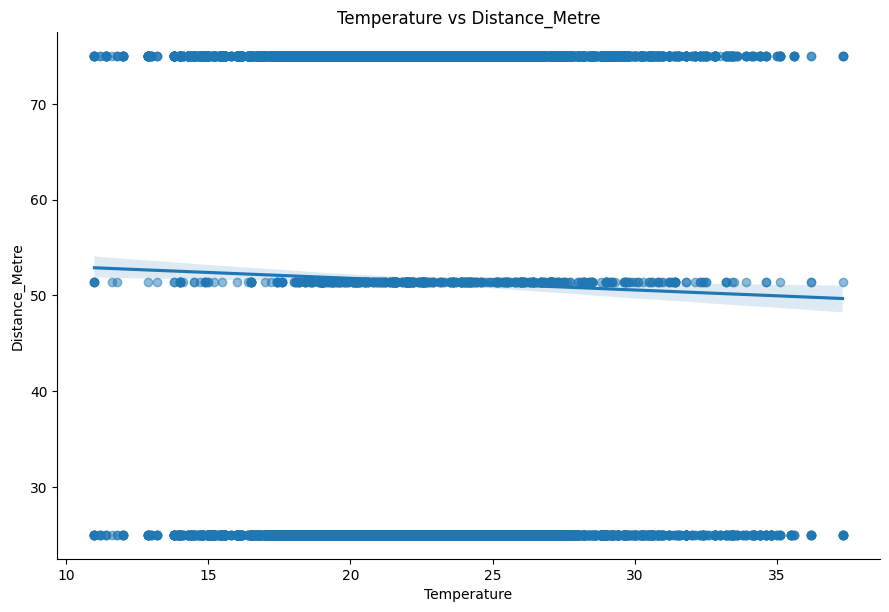

In [ ]:
# Create a scatter plot with a regression line to analyze the relationship between Temperature and Distance_Metre

# Create plot
sns.lmplot(
    x='Temperature',
    y='Distance_Metre',
    data=df,
    aspect=1.5,
    height=6,
    scatter_kws={'alpha':0.5}
)

# Title
plt.title('Temperature vs Distance_Metre')

# Display the plot
plt.show()

## Insights
* There is no strong correlation; observation distances stay relatively constant across temperatures.
* Indicates temperature doesn’t significantly affect detection range, simplifying survey planning.
* Clustered values may reflect limited variation or measurement bias in distance data.

###  Violin Plot: Sky vs Distance

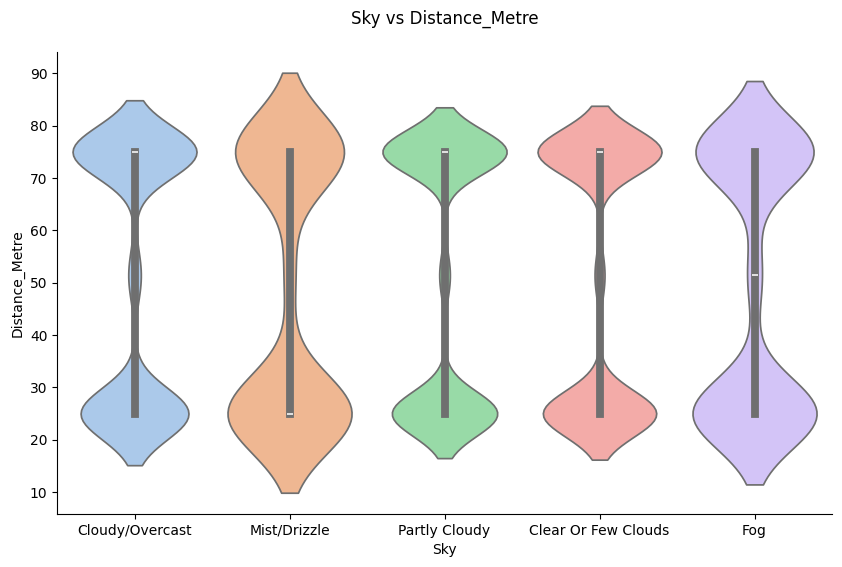

In [ ]:
# Plot a violin plot to explore how Distance_Metre varies across different Sky conditions

# Set Figure Size
plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=df, x='Sky', y='Distance_Metre', palette='pastel')

# Title
plt.title('Sky vs Distance_Metre', pad=20)

# Remove top and right spines
sns.despine()

# Display the plot
plt.show()

## Insights
* To visualize how sky conditions affect the distribution of bird observation distances.
* Observation distances are fairly consistent across sky types, with slightly more spread during mist/drizzle and fog.
* Indicates reliable observation ranges under various sky conditions for field planning.
* Fog and mist may reduce accuracy or consistency in distance estimations.

### Heatmap: Correlation Between Environmental Variables and Distance

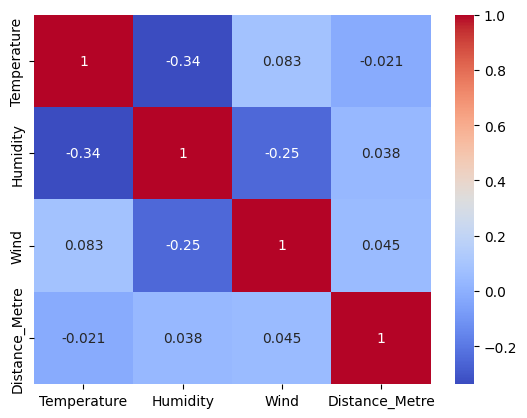

In [ ]:
# Plot a heatmap to visualize correlations between Temperature, Humidity, Wind, and Distance_Metre
sns.heatmap(df[['Temperature','Humidity','Wind','Distance_Metre']].corr(), annot=True, cmap='coolwarm')

# Display the plot
plt.show()

## Insights
* To understand how environmental factors correlate with bird observation distance.
* All variables show very weak correlations with Distance_Metre (near zero).
* Suggests consistent observation distances across varying environmental conditions.
* Lack of strong correlations may indicate missed influencing factors not captured in the data.

### Violin Plot: Distance Distribution by Disturbance

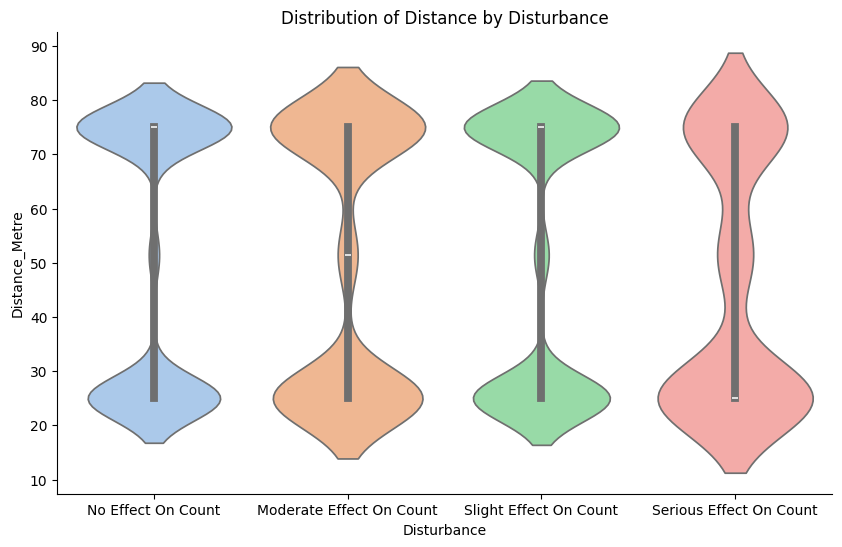

In [ ]:
# Plot a violin plot to show the distribution of observed distances across different disturbance levels

# Set figure size
plt.figure(figsize=(10,6))

# Create plot
sns.violinplot(data=df, x='Disturbance', y='Distance_Metre', palette='pastel')

# Title
plt.title('Distribution of Distance by Disturbance')

# Remove top and right spines
sns.despine()

# Display the plot
plt.show()

## Insights
* To assess how different disturbance levels affect bird observation distances.
* Higher disturbance levels show slightly more spread and variability in distances.
* Helps identify optimal conditions for minimizing disturbance in bird surveys.
* Serious disturbances may cause inconsistent or unreliable distance estimations.

 ## Distance And Behavior

### Bar Plot: Distance analysis

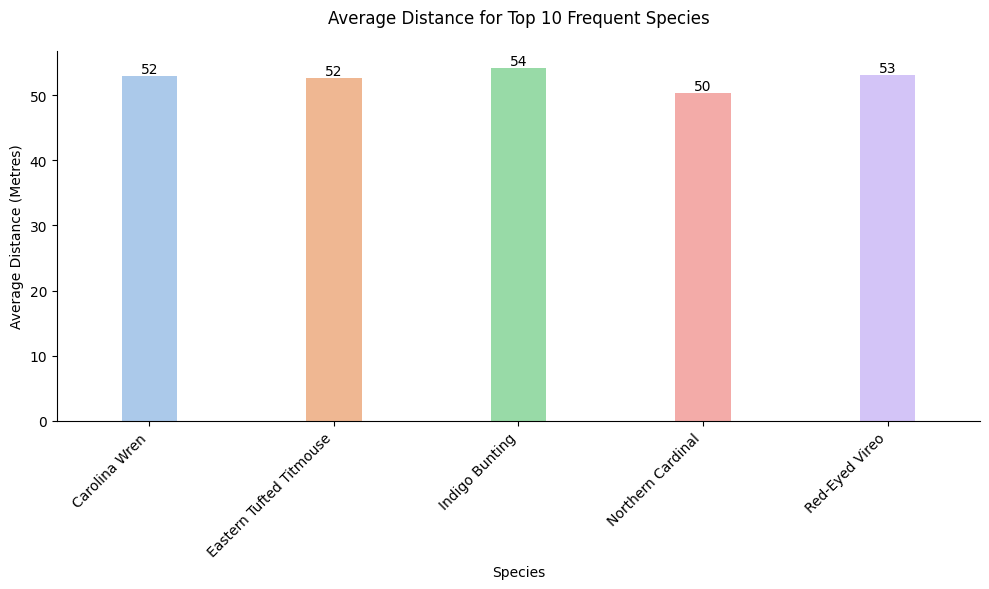

In [ ]:
# Analyze species behavior patterns in relation to their observed distance from the observer

# Top 10 frequent species
top_species = df['Common_Name'].value_counts().head(5).index
df_top = df[df['Common_Name'].isin(top_species)]

# Mean distance per species
distance_stats = df_top.groupby('Common_Name')['Distance_Metre'].mean().reset_index()

# Set figure size
plt.figure(figsize=(10,6))

# Create Plot
ax = sns.barplot(data=distance_stats, x='Common_Name', y='Distance_Metre', width=0.3, palette='pastel')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Title and axis labels
plt.xticks(rotation=45, ha='right')
plt.xlabel("Species")
plt.ylabel("Average Distance (Metres)")
plt.title("Average Distance for Top 10 Frequent Species", pad=20)

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights
* To analyze how far the most frequently observed bird species are typically detected.
* All top 5 species were detected at fairly similar average distances (around 50–54 meters), suggesting uniform detectability.
* Consistent detection range indicates reliable survey methodology for high-frequency species.
* Narrow variance may mask detection challenges for less frequent or quieter species.

 ### Count Plot: Flyover Frequency

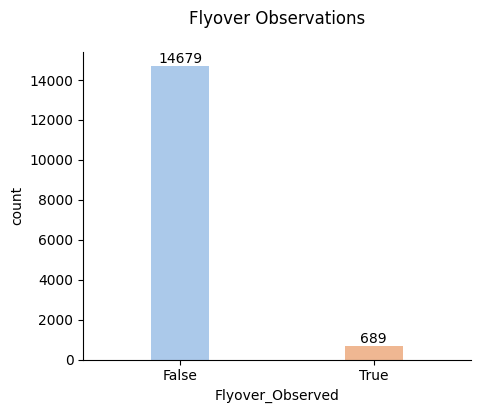

In [ ]:
# Plot a countplot to show the distribution of flyover observations

# Set figure size
plt.figure(figsize=(5,4))

# Create plot
ax = sns.countplot(data=df, x='Flyover_Observed', width=0.3, palette='pastel')
plt.title('Flyover Observations', pad=20)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Remove top and right spines
sns.despine()

# Display the plot
plt.show()

## Insights
* To understand how often birds were recorded flying overhead during observation sessions.
* Flyover observations make up just 4.5% of total sightings.
* Indicates most birds were observed at ground — ideal for identification and counting accuracy.
* missed flyovers may signal a need to improve observer training or include upward scanning in protocols.

## Observer Activity Analysis

### Count Plot: Observations by Each Observer

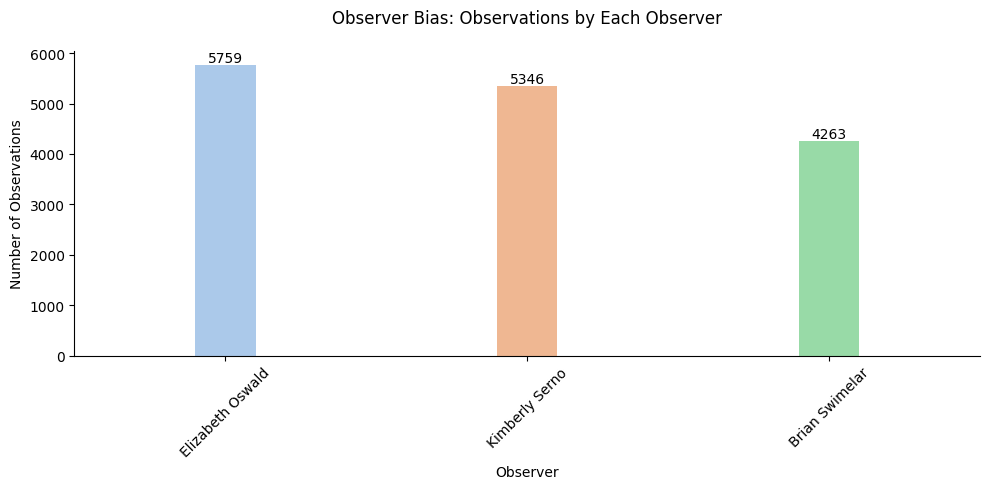

In [ ]:
# Plot a countplot to show the number of observations contributed by each observer

# Set figure size
plt.figure(figsize=(10,5))

# Create plot
ax = sns.countplot(data=df, x='Observer', order=df['Observer'].value_counts().index, width=0.2, palette='pastel')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Title and labels
plt.xticks(rotation=45)
plt.xlabel("Observer")
plt.ylabel("Number of Observations")
plt.title("Observer Bias: Observations by Each Observer", pad=20)

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights
* To examine how observation counts vary by individual observer — helping identify potential observer bias in the data.
* Elizabeth Oswald logged the most observations (5,759), followed by Kimberly Serno (5,346) and Brian Swimelar (4,263), showing a clear effort gap of over 1,500 between Elizabeth and Brian.
* Helps in identifying active contributors for potential outreach, training, or partnership and Weighting data by observer effort.
* Could lead to sampling bias if one observer disproportionately influences trends.

### Step Line Plot: Species Diversity by Visit Number

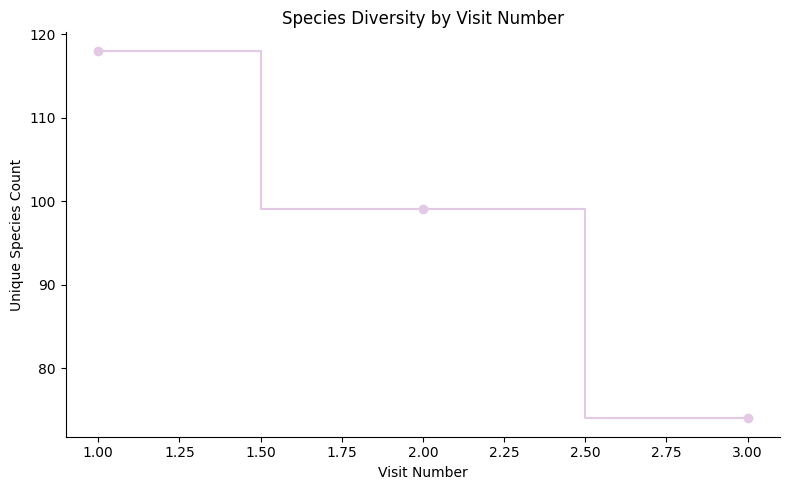

In [ ]:
# Plot a step line chart to show the number of unique species observed in each visit

# Group data by 'Visit' and count unique 'Common_Name' species for each visit
visit_species_count = df.groupby('Visit')['Common_Name'].nunique().reset_index()

# Set figure size
plt.figure(figsize=(8,5))
plt.step(visit_species_count['Visit'], visit_species_count['Common_Name'], where='mid', label='Species Count', color='#E3C9E6')
plt.scatter(visit_species_count['Visit'], visit_species_count['Common_Name'], color='#E3C9E6')

# Title and axis labels
plt.xlabel("Visit Number")
plt.ylabel("Unique Species Count")
plt.title("Species Diversity by Visit Number")

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights
* To track how the number of unique bird species observed changes with each visit.
* Species diversity decreases noticeably after the first visit, suggesting fewer new species are detected in subsequent visits.
* Helps optimize survey efforts by showing diminishing returns in species discovery after initial visits, improving resource allocation.
* Declining species diversity over visits may indicate habitat degradation or observer fatigue, warranting further investigation.

## Conservation Priority Analysis
 Identifies and ranks species or areas based on their urgency for protection to effectively allocate conservation efforts and resources.

### Tree Map: Top 15 AOU Codes

In [ ]:
!pip install squarify

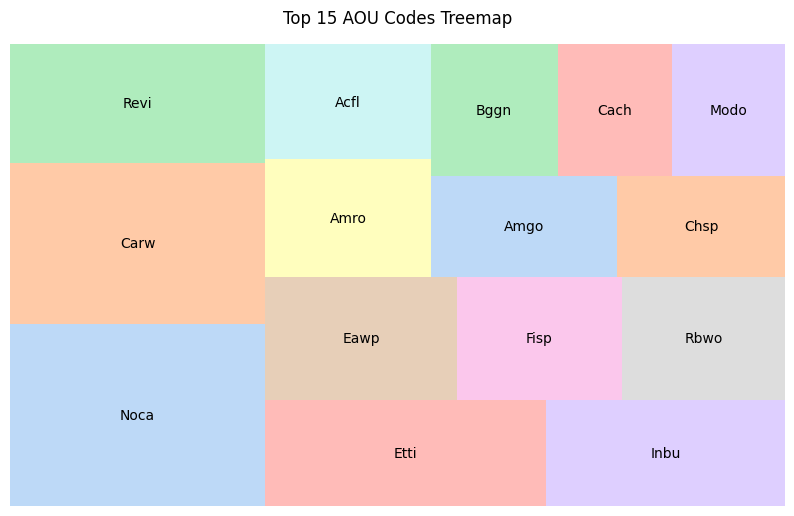

In [ ]:
# Plot a treemap to visualize the top 15 most frequent AOU codes
import squarify
# Top 15 AOU codes
top_aou_counts = df['AOU_Code'].value_counts().head(15)

# Set figure size
plt.figure(figsize=(10,6))

# Generate pastel colors
colors = sns.color_palette("pastel", len(top_aou_counts))

# Plot treemap
squarify.plot(
    sizes=top_aou_counts.values,
    label=top_aou_counts.index,
    color=colors,
    alpha=0.7
)

# Remove axis and set title
plt.axis('off')
plt.title("Top 15 AOU Codes Treemap", pad=15)

# Display the plot
plt.show()

## Insights
* To visually represent the most frequently observed bird species by their AOU codes and their relative counts.
* Helps prioritize conservation efforts or research focus on the most observed species, ensuring effective resource allocation.
* Overrepresentation of certain species may indicate reduced biodiversity requiring targeted investigation.

### Bar Plot: Watchlist Trends by Stewardship Status

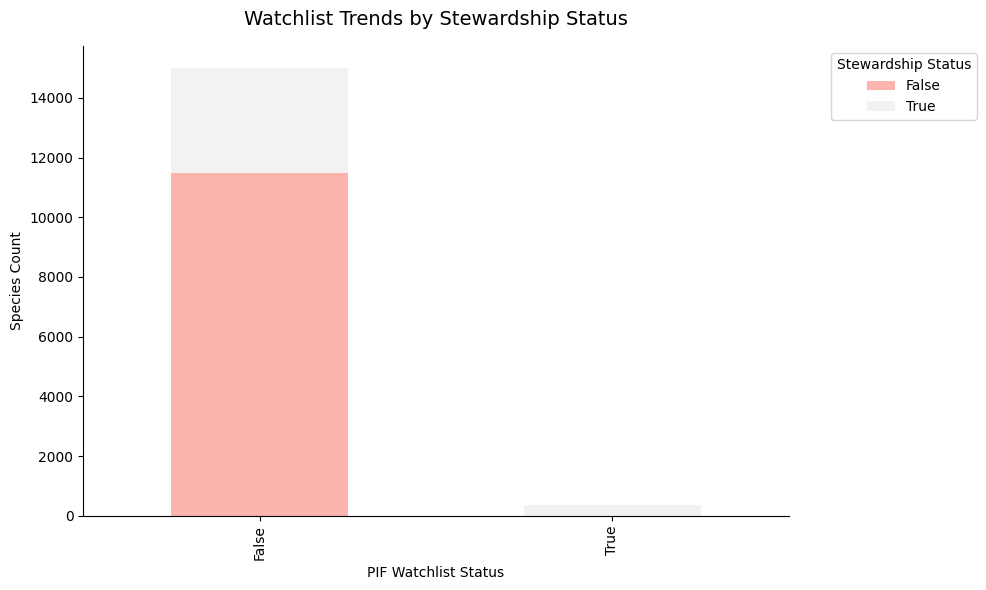

In [ ]:
# Plot a stacked bar chart to show species counts by Watchlist and Stewardship Status

# Create a crosstab for counts
watchlist_ct = pd.crosstab(df['PIF_Watchlist_Status'], df['Regional_Stewardship_Status'])

# Plot stacked bar chart
watchlist_ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Pastel1')

# Add labels and title
plt.title('Watchlist Trends by Stewardship Status', fontsize=14, pad=15)
plt.xlabel('PIF Watchlist Status')
plt.ylabel('Species Count')

# Add legend
plt.legend(title='Stewardship Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right spines
sns.despine()
plt.tight_layout()

# Display the plot
plt.show()

## Insights
* To show the distribution of species counts by PIF watchlist status and their stewardship status.   
* Most species are not on the PIF watchlist and have a stewardship status marked as False.
* Helps prioritize conservation efforts by identifying species that are on the watchlist and require stewardship.
* Low counts of species with both watchlist and stewardship status True may indicate gaps in conservation or monitoring efforts.


### Pair Plot:  Shows relationships among numeric variables.

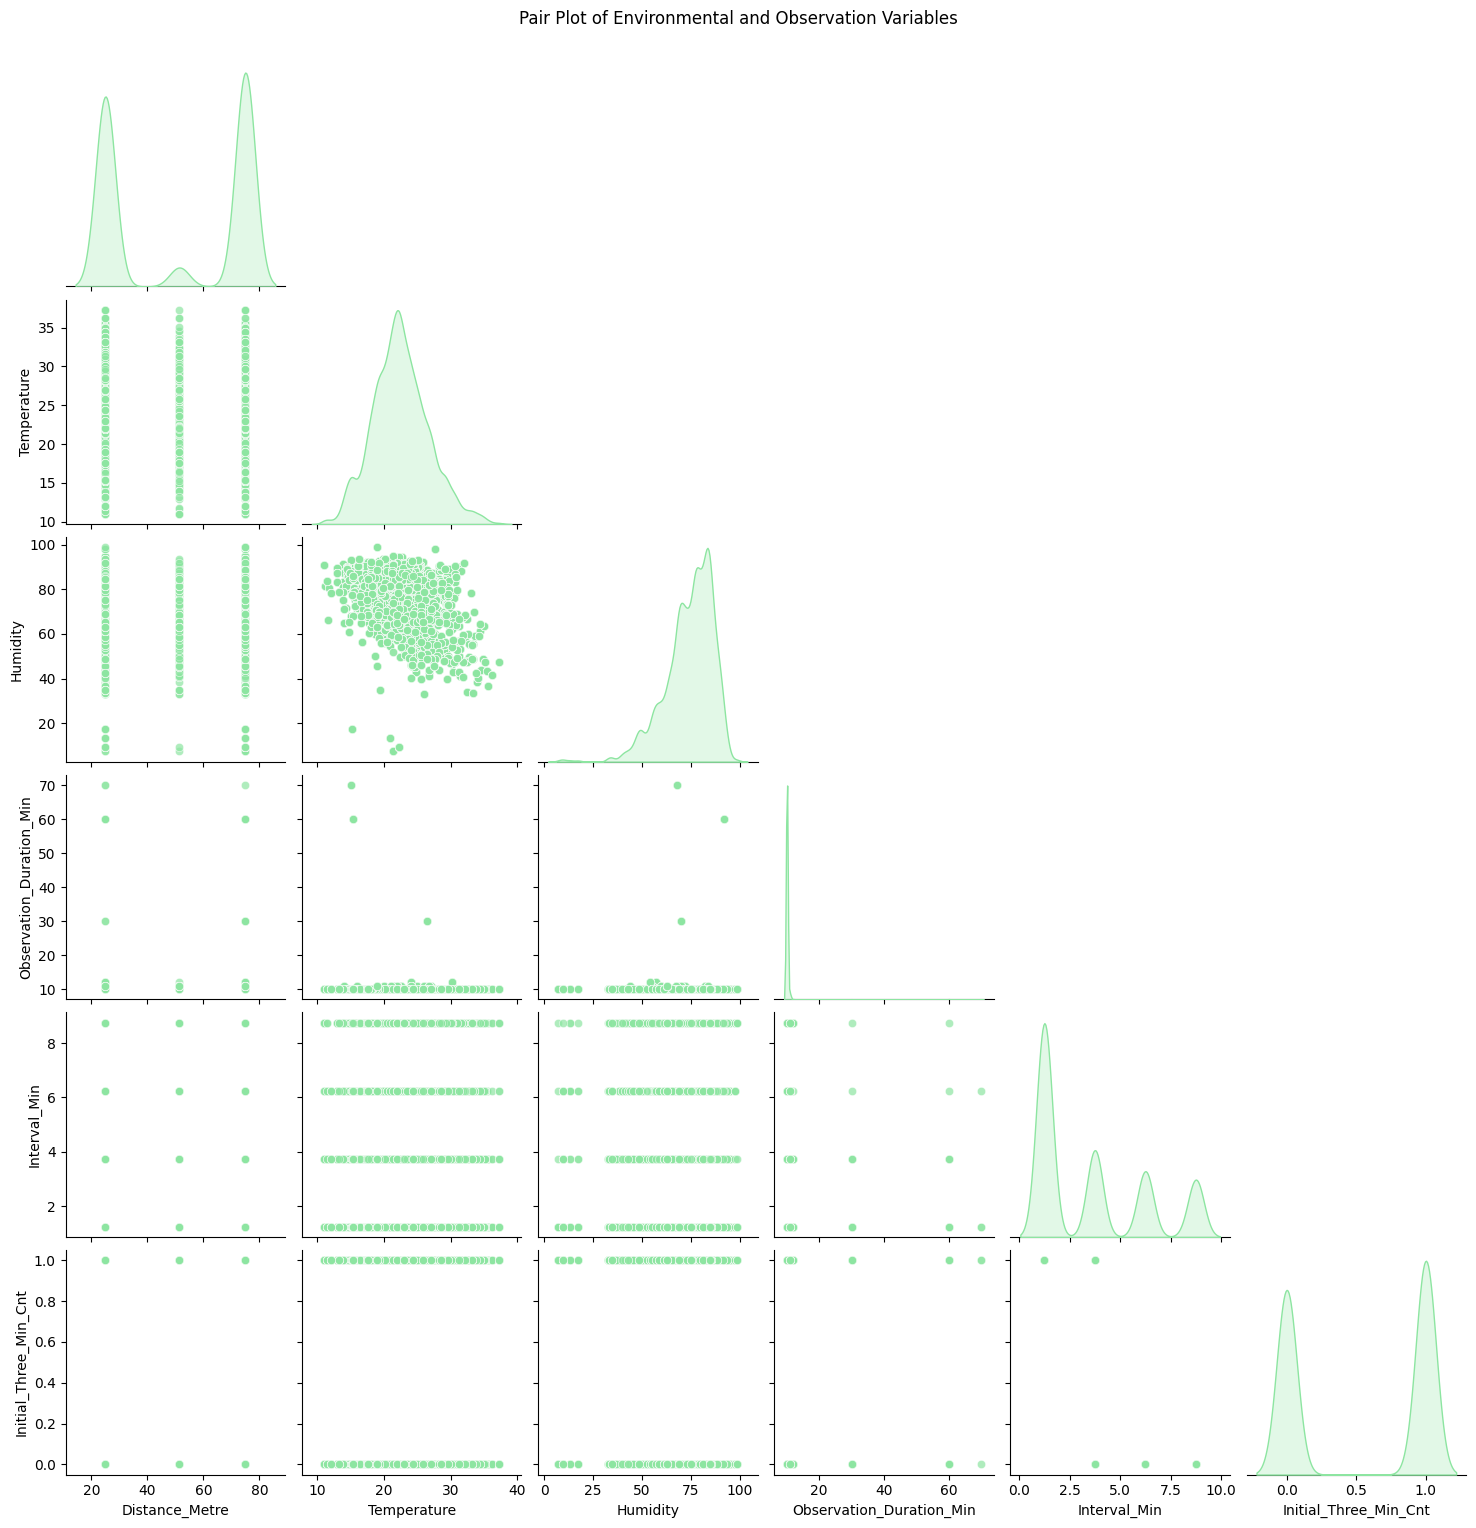

In [ ]:
# Pair plot of key environmental and observation metrics

# Select numeric columns
num_cols = ['Distance_Metre', 'Temperature', 'Humidity',
            'Observation_Duration_Min', 'Interval_Min', 'Initial_Three_Min_Cnt']

pastel_color = sns.color_palette("pastel")[2]

# Create plot
sns.pairplot(
    df[num_cols],
    diag_kind='kde',
    corner=True,
    plot_kws={'color': pastel_color, 'alpha': 0.7},
    diag_kws={'color': pastel_color}
)

# Title
plt.suptitle("Pair Plot of Environmental and Observation Variables", y=1.02)

# Display the plot
plt.show()

To explore relationships and distributions among key environmental and observation variables in the bird species dataset.

## **Actionable Strategy for Growth**

- **Optimize Field Surveys**: Schedule monitoring during high-activity months (May–June) and peak hours (early mornings) to maximize species detection rates.
- **Prioritize Hotspot Protection**: Focus conservation resources on high-biodiversity plots in both forest and grassland habitats, ensuring balanced protection efforts.
- **Refine Data Collection**: Address observer bias by distributing survey effort evenly and improving sampling for underrepresented species or sex categories.
- **Mitigate Environmental Disturbances**: Implement measures to reduce human and environmental disruptions in sensitive plots to maintain consistent detection rates.
- **Target Conservation Actions**: Use species-level watchlist and stewardship data to allocate resources toward at-risk species and habitats needing immediate intervention.
- **Enhance Public Engagement**: Share hotspot and seasonal activity findings with eco-tourism and local communities to foster awareness and support for habitat protection.

# **Conclusion**

This analysis provided a clear understanding of bird species diversity, seasonal activity patterns, habitat preferences, and behavioural trends across forest and grassland ecosystems. By combining robust data preparation with targeted visual exploration, the study identified key biodiversity hotspots, optimal survey timings, and species-specific conservation priorities. These insights form a practical foundation for improving field survey efficiency, reducing data collection bias, and guiding conservation strategies to protect at-risk species and habitats effectively.

